# Visualizaciones TPF Super-Resolución (local)

Notebook que junta TODO: corre la evaluación, genera tablas/paneles/curvas/benchmark y los
muestra inline. Usa los pesos que haya en `outputs/`.

**Cómo correrlo:** abrilo con el kernel del venv del proyecto (`.venv`). Si usás VSCode/Jupyter,
seleccioná `.venv/bin/python` como kernel. No entrena nada: solo lee pesos y dibuja.

Ajustá `SCALES` y `TESTSETS` abajo: con los 4 modelos actuales usá `2 4` / `Set5 Set14`;
después del entrenamiento completo en Kaggle, `2 3 4` / `Set5 Set14 BSD100 Urban100`.

In [8]:
%pip install --upgrade pip
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 3.9 MB/s  0:00:03 eta 0:00:01
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Parametros
SCALES = '2 4'              # despues de Kaggle: '2 3 4'
TESTSETS = 'Set5 Set14'    # despues de Kaggle: 'Set5 Set14 BSD100 Urban100'
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('')), 'src'))
print('cwd:', os.getcwd())

cwd: /Users/frino/Desktop/Udesa/3 AÑO/Vision/Final-final/src


In [9]:
# 1) Generar tablas + paneles + curvas (make_figures) y benchmark (bench)
#    Se corren como subproceso para no mezclar backends de matplotlib.
!python make_figures.py --scales {SCALES} --testsets {TESTSETS} --panels 0 2
!python bench.py --scales {SCALES}

device=mps
# Resultados — PSNR / SSIM (canal Y, con shave)


## Factor x2

| Método | Set5 PSNR | Set5 SSIM | Set14 PSNR | Set14 SSIM |
|---|---|---|---|---|
| nearest | 30.86 | 0.9105 | 28.58 | 0.8606 |
| bilinear | 32.25 | 0.9194 | 29.25 | 0.8534 |
| bicubic | 33.68 | 0.9370 | 30.33 | 0.8815 |
| **fsrcnn_res_x2_l1** | **36.98** | **0.9615** | **32.64** | **0.9169** |
| **fsrcnn_x2_l1** | **36.84** | **0.9611** | **32.53** | **0.9162** |

## Factor x4

| Método | Set5 PSNR | Set5 SSIM | Set14 PSNR | Set14 SSIM |
|---|---|---|---|---|
| nearest | 26.26 | 0.7640 | 24.74 | 0.6814 |
| bilinear | 27.56 | 0.7992 | 25.51 | 0.6959 |
| bicubic | 28.43 | 0.8232 | 26.09 | 0.7217 |
| **fsrcnn_res_x4_l1** | **30.78** | **0.8828** | **27.72** | **0.7761** |
| **fsrcnn_x4_l1** | **30.62** | **0.8795** | **27.62** | **0.7743** |
ok -> /Users/frino/Desktop/Udesa/3 AÑO/Vision/Final-final/src/../outputs/figures/conv_x2.png
ok -> /Users/frino/Desktop/Udesa/3 AÑO/Vision/Final-final/src/../outputs/figure

In [10]:
# 2) Mostrar las TABLAS inline
from IPython.display import Markdown, display
for f in ['../outputs/tables.md', '../outputs/bench.md']:
    if os.path.exists(f):
        display(Markdown(open(f).read()))

# Resultados — PSNR / SSIM (canal Y, con shave)


## Factor x2

| Método | Set5 PSNR | Set5 SSIM | Set14 PSNR | Set14 SSIM |
|---|---|---|---|---|
| nearest | 30.86 | 0.9105 | 28.58 | 0.8606 |
| bilinear | 32.25 | 0.9194 | 29.25 | 0.8534 |
| bicubic | 33.68 | 0.9370 | 30.33 | 0.8815 |
| **fsrcnn_res_x2_l1** | **36.98** | **0.9615** | **32.64** | **0.9169** |
| **fsrcnn_x2_l1** | **36.84** | **0.9611** | **32.53** | **0.9162** |

## Factor x4

| Método | Set5 PSNR | Set5 SSIM | Set14 PSNR | Set14 SSIM |
|---|---|---|---|---|
| nearest | 26.26 | 0.7640 | 24.74 | 0.6814 |
| bilinear | 27.56 | 0.7992 | 25.51 | 0.6959 |
| bicubic | 28.43 | 0.8232 | 26.09 | 0.7217 |
| **fsrcnn_res_x4_l1** | **30.78** | **0.8828** | **27.72** | **0.7761** |
| **fsrcnn_x4_l1** | **30.62** | **0.8795** | **27.62** | **0.7743** |


# Eficiencia — parámetros, latencia, FPS


## Factor x2 (device=mps)

| Modelo | Params | ms/img | FPS | Set5 PSNR |
|---|---|---|---|---|
| fsrcnn_res_x2_l1 | 12,809 | 1.96 | 509.5 | 36.98 |
| fsrcnn_x2_l1 | 12,809 | 1.23 | 810.5 | 36.84 |

## Factor x4 (device=mps)

| Modelo | Params | ms/img | FPS | Set5 PSNR |
|---|---|---|---|---|
| fsrcnn_res_x4_l1 | 12,809 | 2.21 | 452.6 | 30.78 |
| fsrcnn_x4_l1 | 12,809 | 0.48 | 2099.9 | 30.62 |


../outputs/figures/conv_x2.png


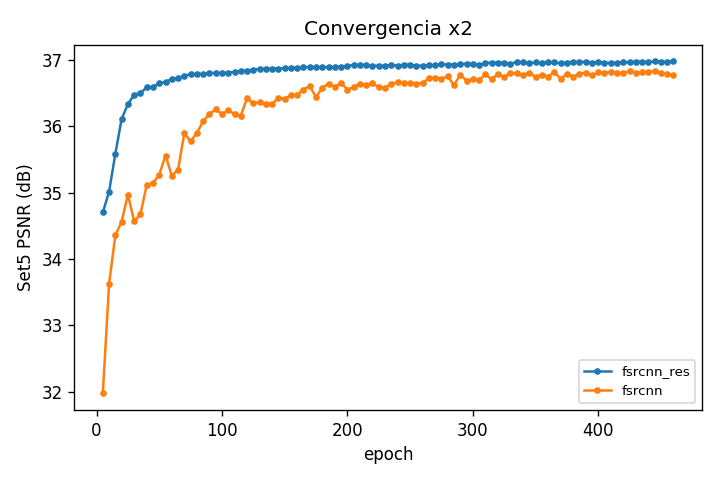

../outputs/figures/conv_x4.png


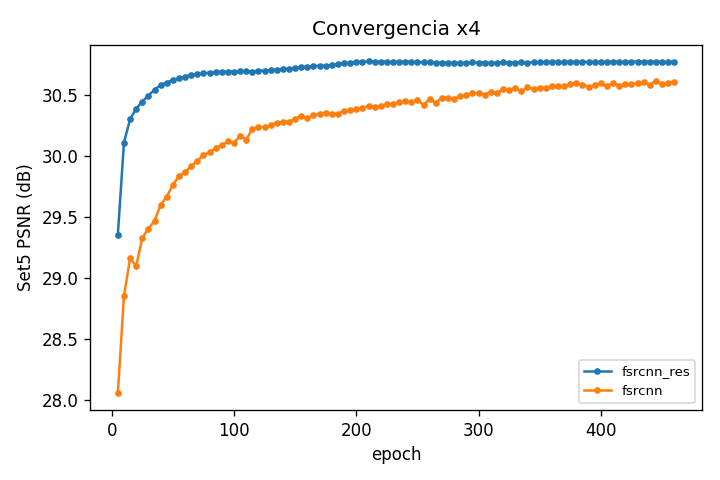

../outputs/figures/panel_Set5_x2_0.png


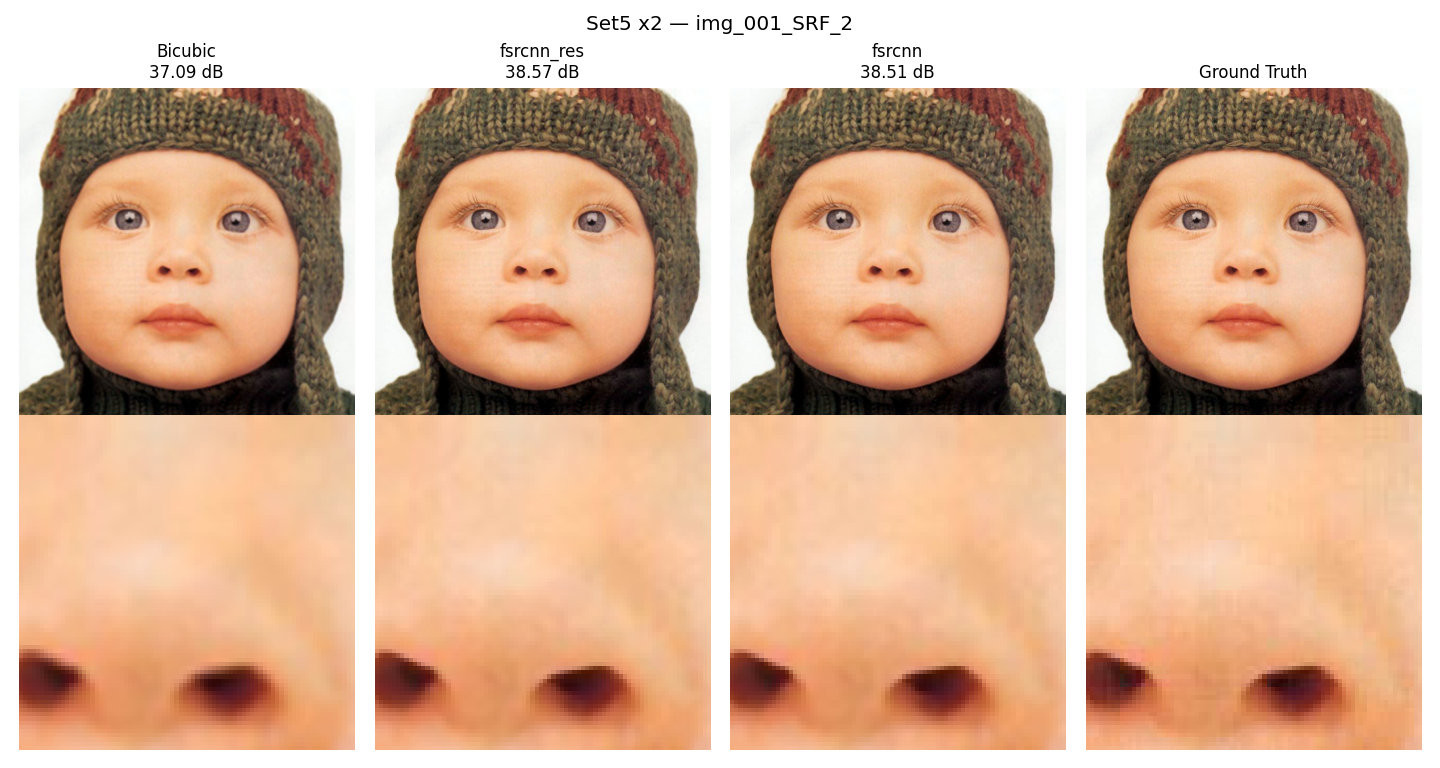

../outputs/figures/panel_Set5_x2_2.png


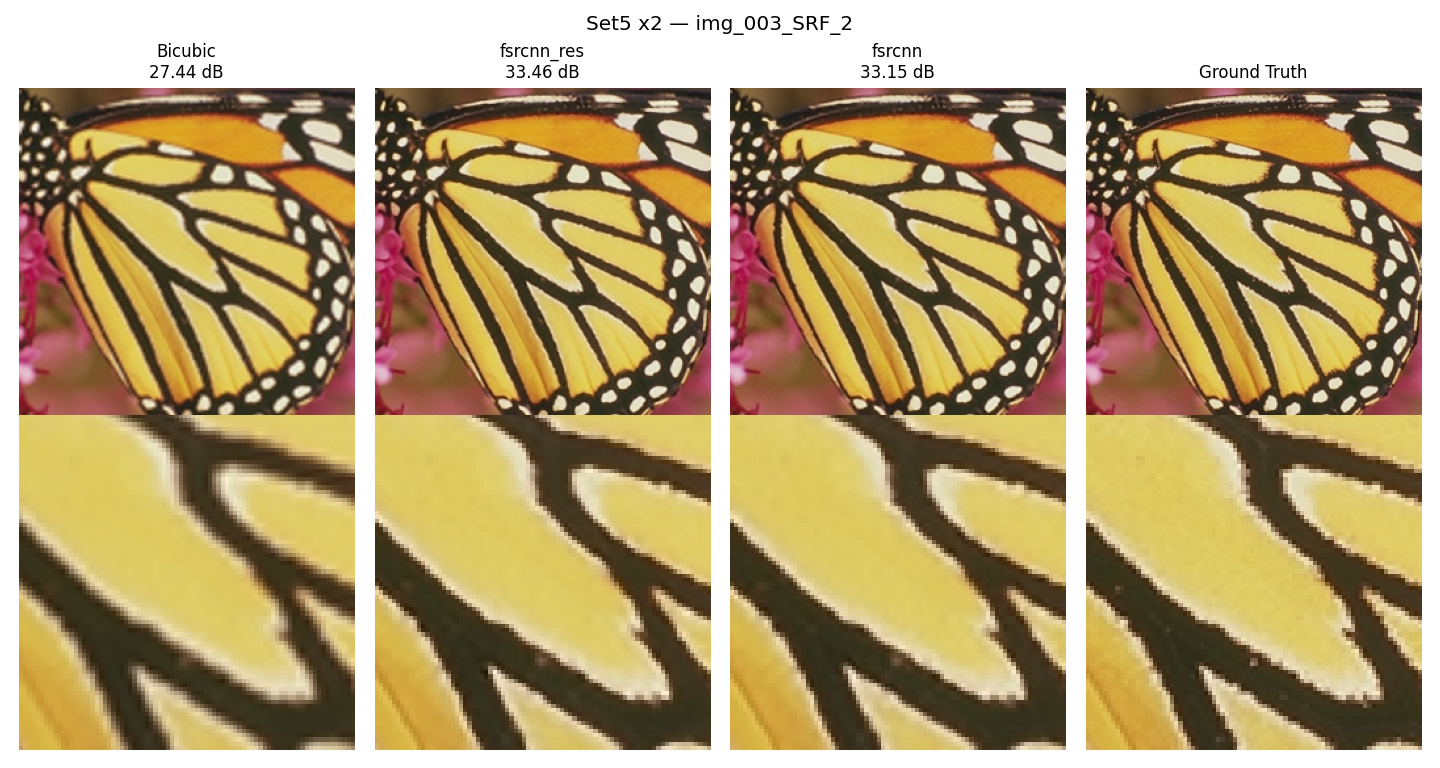

../outputs/figures/panel_Set5_x4_0.png


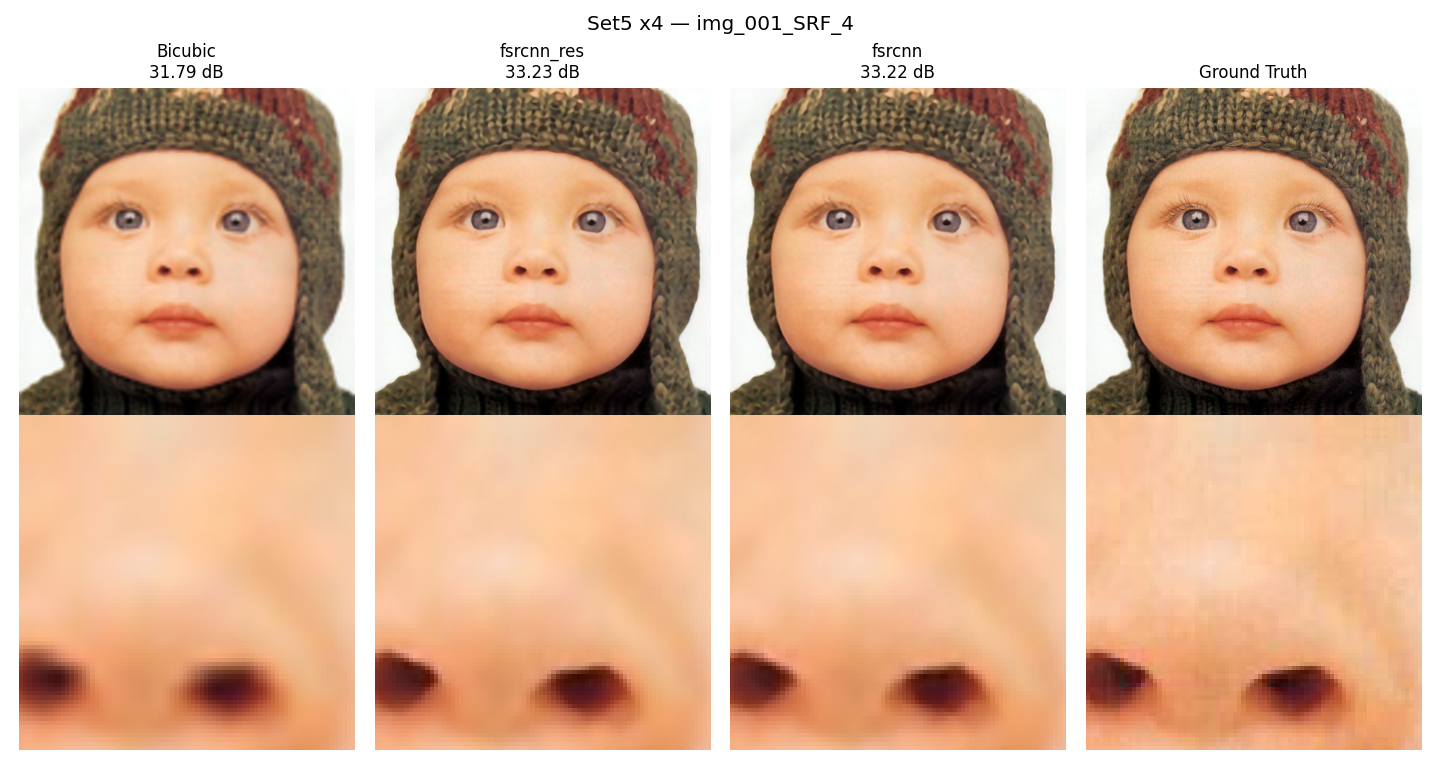

../outputs/figures/panel_Set5_x4_2.png


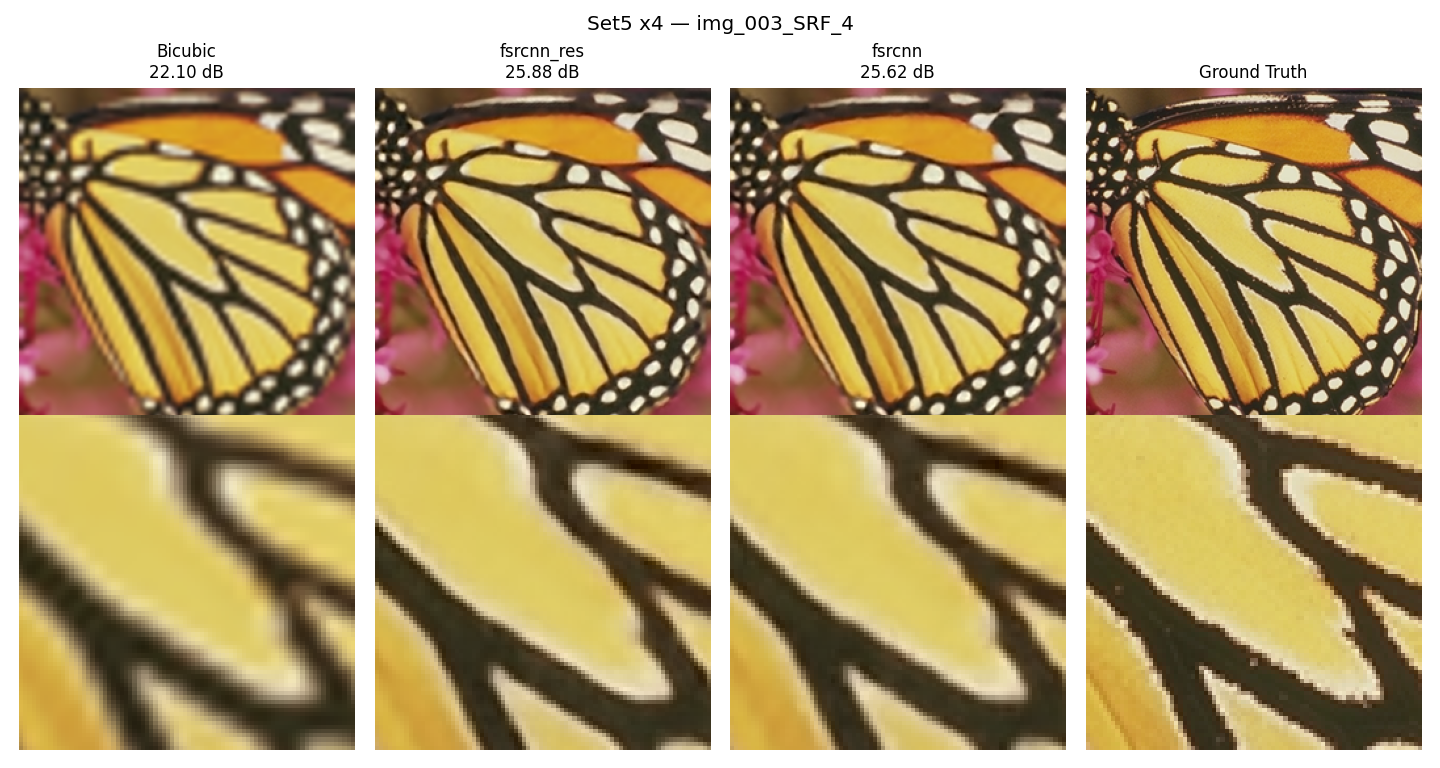

../outputs/figures/speed_x2.png


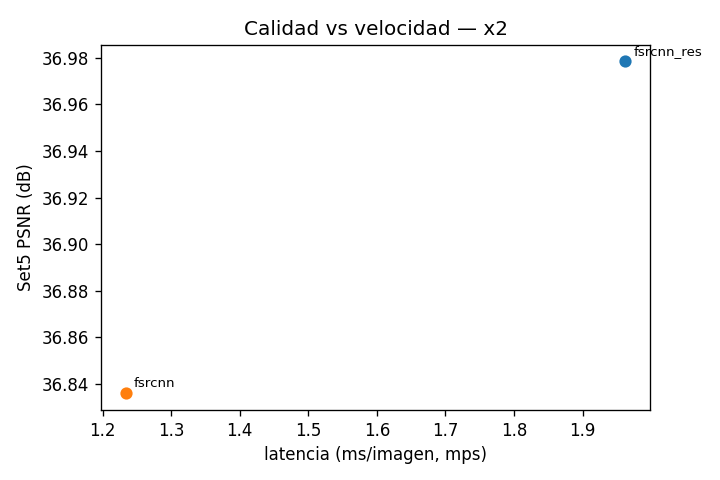

../outputs/figures/speed_x4.png


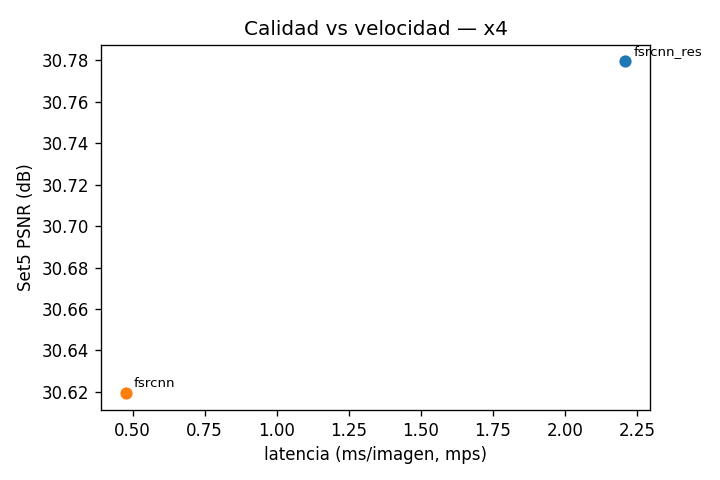

In [11]:
# 3) Mostrar TODAS las figuras generadas inline
import glob
from IPython.display import Image, display
for p in sorted(glob.glob('../outputs/figures/*.png')):
    print(p)
    display(Image(p))

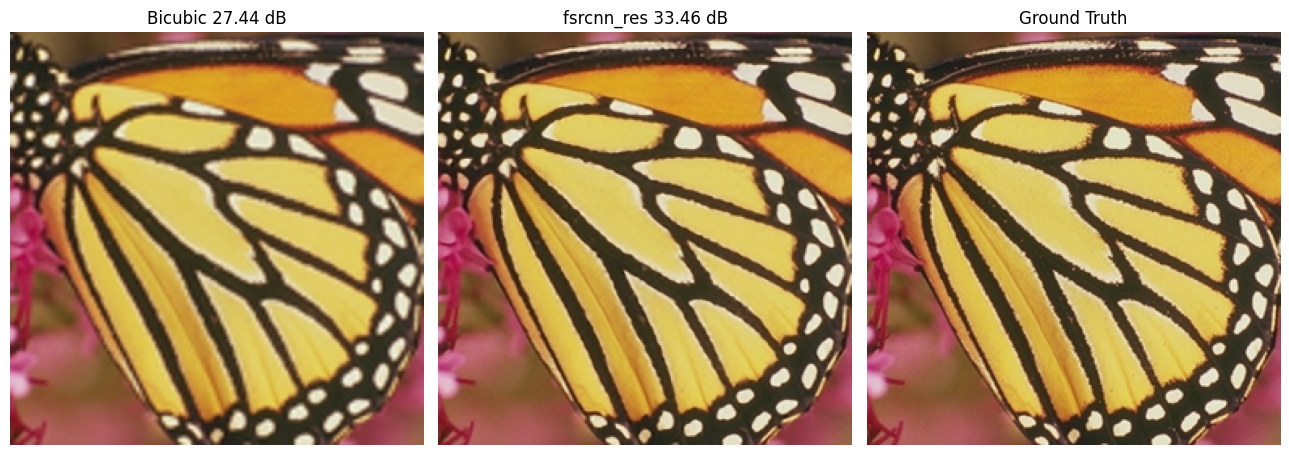

In [12]:
# 4) DEMO interactiva: super-resolucionar una imagen con un modelo a eleccion
%matplotlib inline
import torch, numpy as np, matplotlib.pyplot as plt
from eval import load_set, sr_from_model, rgb2y, _psnr_arr
from baselines import upsample_to
from models import build_model

# --- elegi aca ---
TAG, ARCH, SCALE, DATASET, IDX = 'fsrcnn_res_x2_l1', 'fsrcnn_res', 2, 'Set5', 2

dev = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
m = build_model(ARCH, SCALE).to(dev)
m.load_state_dict(torch.load(f'../outputs/{TAG}/best.pth', map_location=dev)); m.eval()
it = load_set(DATASET, SCALE)[IDX]
bic = upsample_to(it['lr'], it['hr'].shape[:2], 'bicubic')
sr, y_sr = sr_from_model(m, it['lr'], SCALE, dev)
y_hr = rgb2y(it['hr'])[:y_sr.shape[0], :y_sr.shape[1]]
p_bic = _psnr_arr(rgb2y(bic), rgb2y(it['hr'])[:bic.shape[0], :bic.shape[1]], SCALE)
p_sr = _psnr_arr(y_sr, y_hr, SCALE)

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
for a, img, t in zip(ax, [bic, sr, it['hr']],
                     [f'Bicubic {p_bic:.2f} dB', f'{ARCH} {p_sr:.2f} dB', 'Ground Truth']):
    a.imshow(img); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()